<a href="https://colab.research.google.com/github/Jorge-Cano96/computacion-nube/blob/main/Practica2_laboratorio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Generamos datos simulados de demanda eléctrica (kW)
fechas = pd.date_range(start='2024-01-01', periods=365, freq='D')
np.random.seed(42)

demanda = (
    200 +                                    # base
    30 * np.sin(2 * np.pi * np.arange(365) / 365) +  # estacionalidad anual
    np.random.normal(0, 10, 365)             # ruido
)

df = pd.DataFrame({'fecha': fechas, 'demanda_kW': demanda})
df.set_index('fecha', inplace=True)
print(df.head(10))

            demanda_kW
fecha                 
2024-01-01  204.967142
2024-01-02  199.133758
2024-01-03  207.509534
2024-01-04  216.778889
2024-01-05  199.722539
2024-01-06  200.237574
2024-01-07  218.885179
2024-01-08  211.280589
2024-01-09  199.423619
2024-01-10  210.054865


In [3]:
print("=== ESTRUCTURA ===")
print(df.info())
print("\n=== VALORES FALTANTES ===")
print(df.isnull().sum())
print("\n=== PRIMEROS Y ÚLTIMOS REGISTROS ===")
print(df.head(3))
print(df.tail(3))

=== ESTRUCTURA ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 365 entries, 2024-01-01 to 2024-12-30
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   demanda_kW  365 non-null    float64
dtypes: float64(1)
memory usage: 5.7 KB
None

=== VALORES FALTANTES ===
demanda_kW    0
dtype: int64

=== PRIMEROS Y ÚLTIMOS REGISTROS ===
            demanda_kW
fecha                 
2024-01-01  204.967142
2024-01-02  199.133758
2024-01-03  207.509534
            demanda_kW
fecha                 
2024-12-28  197.363808
2024-12-29  202.984469
2024-12-30  206.385039


In [4]:
print("=== ESTADÍSTICAS BÁSICAS ===")
print(df.describe().round(2))

print(f"\nMedia:   {df['demanda_kW'].mean():.2f} kW")
print(f"Mediana: {df['demanda_kW'].median():.2f} kW")
print(f"Mínimo:  {df['demanda_kW'].min():.2f} kW")
print(f"Máximo:  {df['demanda_kW'].max():.2f} kW")
print(f"Std Dev: {df['demanda_kW'].std():.2f} kW")

=== ESTADÍSTICAS BÁSICAS ===
       demanda_kW
count      365.00
mean       200.10
std         22.89
min        138.20
25%        181.37
50%        200.07
75%        218.95
max        252.55

Media:   200.10 kW
Mediana: 200.07 kW
Mínimo:  138.20 kW
Máximo:  252.55 kW
Std Dev: 22.89 kW


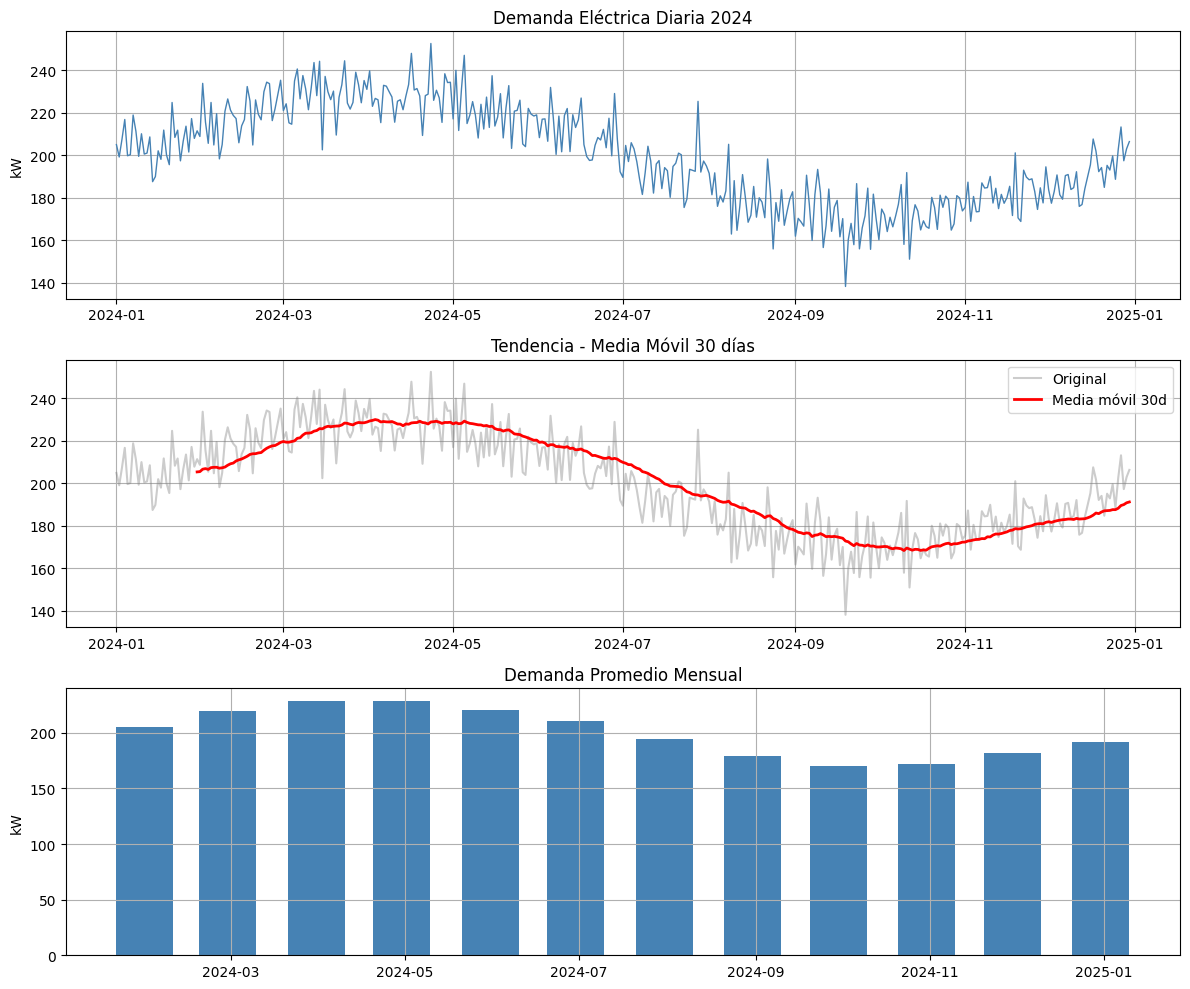

In [5]:
fig, axs = plt.subplots(3, 1, figsize=(12, 10))

# Gráfica 1: Serie completa
axs[0].plot(df.index, df['demanda_kW'], color='steelblue', linewidth=1)
axs[0].set_title('Demanda Eléctrica Diaria 2024')
axs[0].set_ylabel('kW')
axs[0].grid(True)

# Gráfica 2: Promedio móvil 30 días
df['media_movil'] = df['demanda_kW'].rolling(window=30).mean()
axs[1].plot(df.index, df['demanda_kW'], alpha=0.4, color='gray', label='Original')
axs[1].plot(df.index, df['media_movil'], color='red', linewidth=2, label='Media móvil 30d')
axs[1].set_title('Tendencia - Media Móvil 30 días')
axs[1].legend()
axs[1].grid(True)

# Gráfica 3: Promedio mensual
df_mensual = df['demanda_kW'].resample('ME').mean()
axs[2].bar(df_mensual.index, df_mensual.values, color='steelblue', width=20)
axs[2].set_title('Demanda Promedio Mensual')
axs[2].set_ylabel('kW')
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [7]:
media = df['demanda_kW'].mean()
cv = df['demanda_kW'].std() / media * 100
minimo = df['demanda_kW'].min()
maximo = df['demanda_kW'].max()

print("=== CONCLUSIONES DEL ANÁLISIS ===")
print(f"1. TENDENCIA: Estacionalidad anual clara")
print(f"   - Pico maximo: primer semestre (~230 kW)")
print(f"   - Valle minimo: tercer trimestre (~165 kW)")
print(f"\n2. ESTADISTICA:")
print(f"   - Media:        {media:.1f} kW")
print(f"   - Variabilidad: {cv:.1f}%")
print(f"   - Rango:        {minimo:.1f} - {maximo:.1f} kW")
print(f"\n3. CALIDAD DE DATOS:")
print(f"   - Registros: 365 dias completos")
print(f"   - Valores faltantes: 0")
print(f"\n4. ANOMALIAS VISUALES:")
print(f"   - Caida abrupta en julio-agosto 2024")
print(f"   - Posible evento operativo o error de medicion")

=== CONCLUSIONES DEL ANÁLISIS ===
1. TENDENCIA: Estacionalidad anual clara
   - Pico maximo: primer semestre (~230 kW)
   - Valle minimo: tercer trimestre (~165 kW)

2. ESTADISTICA:
   - Media:        200.1 kW
   - Variabilidad: 11.4%
   - Rango:        138.2 - 252.6 kW

3. CALIDAD DE DATOS:
   - Registros: 365 dias completos
   - Valores faltantes: 0

4. ANOMALIAS VISUALES:
   - Caida abrupta en julio-agosto 2024
   - Posible evento operativo o error de medicion


In [8]:
# Guardar gráficas como archivos PNG
fig.savefig('grafica_demanda.png', dpi=150, bbox_inches='tight')
print("Imagen guardada!")

Imagen guardada!
